In [ ]:
# python notebook for Make Your Own Neural Network
# working with the MNIST data set
#
# (c) Tariq Rashid, 2016
# license is GPLv2

In [1]:
import numpy
import matplotlib.pyplot
%matplotlib inline

In [1]:
# open the CSV file and read its contents into a list
data_file = open("mnist_dataset/mnist_train.csv", 'r')
data_list = data_file.readlines()
data_file.close()

In [5]:
# check the number of data records (examples)
len(data_list)

60000

In [6]:
# show a dataset record
# the first number is the label, the rest are pixel colour values (greyscale 0-255)
data_list[0]

'5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,18,18,18,126,136,175,26,166,255,247,127,0,0,0,0,0,0,0,0,0,0,0,0,30,36,94,154,170,253,253,253,253,253,225,172,253,242,195,64,0,0,0,0,0,0,0,0,0,0,0,49,238,253,253,253,253,253,253,253,253,251,93,82,82,56,39,0,0,0,0,0,0,0,0,0,0,0,0,18,219,253,253,253,253,253,198,182,247,241,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,80,156,107,253,253,205,11,0,43,154,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14,1,154,253,90,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,139,253,190,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11,190,253,70,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,35,241,225,160,108,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,81,240,253,253,119,25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

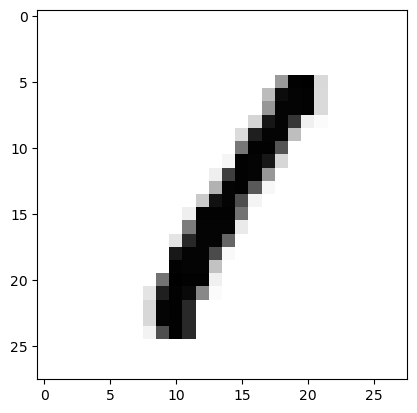

In [7]:
# import numpy
# import matplotlib.pyplot
# take the data from a record, rearrange it into a 28*28 array and plot it as an image

# 두번째 데이터를 가져와서 ,로 구분
all_values = data_list[3].split(',')

#image_array = numpy.asfarray(all_values[1:]).reshape((28,28))

#convert to float for better plotting 한것을 asarray 할때 dtype=float 추가
image_array = numpy.asarray(all_values[1:], dtype=float).reshape((28,28))  

matplotlib.pyplot.imshow(image_array, cmap='Greys', interpolation='None')

In [8]:
# scale input 을 0.01~1.00 사이로 스케일링 for the neural network 

# scaled_input = (numpy.asfarray(all_values[1:]) / 255.0 * 0.99) + 0.01

# 입력값 (위에서 load 한 학습데이터 파일) 을 활성화 함수에 넣기 좋게 0.01~1.00 사이로 스케일링한 값
# 255 로 나누고 0.99 곱하고 0.01 더함
scaled_input = (numpy.asarray(all_values[1:], dtype=float) / 255.0 * 0.99) + 0.01

print(scaled_input)

[0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0

In [9]:
#output nodes is 10 (example)
onodes = 10
targets = numpy.zeros(onodes) + 0.01
print (targets)
targets[int(all_values[0])] = 0.99
print (all_values[0])
print (targets)

[0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]
1
[0.01 0.99 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]


In [29]:
print(targets)

[0.01 0.99 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]
